In [41]:
import karman
import pandas as pd
import numpy as np
import torch

In [44]:
device = 'cpu'
torch_type = 'float32'
batch_size = 64
normalization_dict_path = None
model_path = None
lr = 0.001
run_name = ''
thermo_path = '/shared/us-hl-therm-landing/satellites_data_w_sw_2mln.csv'
epochs = 5
num_workers = 16
min_date = '2000-07-29 00:59:47'
max_date = '2024-05-31 23:59:32'
omni_indices_path = '/shared/us-hl-therm-landing/omniweb_data/merged_omni_indices.csv'
omni_magnetic_field_path = '/shared/us-hl-therm-landing/omniweb_data/merged_omni_magnetic_field.csv'
omni_solar_wind_path = '/shared/us-hl-therm-landing/omniweb_data/merged_omni_solar_wind.csv'
nrlmsise00_path = '/shared/us-hl-therm-landing/nrlmsise00_data/nrlmsise00_time_series.csv'
goes_path = None
soho_path = '/shared/us-hl-therm-landing/soho_data/soho_data.csv'
lag_minutes = 0
resolution_minutes = 10
dropout = 0.05
state_size = 64
lstm_layers = 2
attention_heads = 4
wandb_inactive = False
features_to_exclude_thermo = []

In [45]:
karman_dataset = karman.KarmanDataset(
    thermo_path=thermo_path,
    min_date=pd.to_datetime(min_date),
    max_date=pd.to_datetime(max_date),
    normalization_dict=None,
    nrlmsise00_path=nrlmsise00_path,
    omni_indices_path=omni_indices_path,
    omni_magnetic_field_path=omni_magnetic_field_path,
    omni_solar_wind_path=omni_solar_wind_path,
    soho_path=soho_path,
    lag_minutes_nrlmsise00=lag_minutes,
    nrlmsise00_resolution=resolution_minutes,
    lag_minutes_omni=lag_minutes,
    omni_resolution=resolution_minutes,
    lag_minutes_soho=lag_minutes,
    soho_resolution=resolution_minutes,
    # features_to_exclude_thermo=features_to_exclude_thermo
)

Loading Omni indices.


/home/jordivilaperez/2024-HL-Thermo-CL/karman/dataset.py:469: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.time_series_data[data_name]["data"] = self.time_series_data[data_name]["data"].interpolate(method="pad")
/home/jordivilaperez/2024-HL-Thermo-CL/karman/dataset.py:472: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.time_series_data[data_name]["data"] = (self.time_series_data[data_name]["data"].resample(f"{resolution}T").ffill())


Loading Omni Solar Wind.


/home/jordivilaperez/2024-HL-Thermo-CL/karman/dataset.py:469: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.time_series_data[data_name]["data"] = self.time_series_data[data_name]["data"].interpolate(method="pad")
/home/jordivilaperez/2024-HL-Thermo-CL/karman/dataset.py:472: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.time_series_data[data_name]["data"] = (self.time_series_data[data_name]["data"].resample(f"{resolution}T").ffill())


Loading Omni Magnetic Field.


...

Loading SOHO.


/home/jordivilaperez/2024-HL-Thermo-CL/karman/dataset.py:469: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.time_series_data[data_name]["data"] = self.time_series_data[data_name]["data"].interpolate(method="pad")
/home/jordivilaperez/2024-HL-Thermo-CL/karman/dataset.py:472: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.time_series_data[data_name]["data"] = (self.time_series_data[data_name]["data"].resample(f"{resolution}T").ffill())


Creating thermospheric density dataset
Removing from the data errors in mean absolute percentage error 200% or more in the density (between nrlmsise00 and ground truth)
loading it from file
Used features: Index(['tudelft_thermo__altitude__[m]', 'tudelft_thermo__latitude__[deg]',
       'celestrack__ap_average__',
       'space_environment_technologies__f107_obs__',
       'space_environment_technologies__f107_average__',
       'space_environment_technologies__s107_obs__',
       'space_environment_technologies__s107_average__',
       'space_environment_technologies__m107_obs__',
       'space_environment_technologies__m107_average__',
       'space_environment_technologies__y107_obs__',
       'space_environment_technologies__y107_average__', 'JB08__d_st_dt__[K]',
       'tudelft_thermo__longitude__[deg]_sin',
       'tudelft_thermo__longitude__[deg]_cos', 'all__day_of_year__[d]_sin',
       'all__day_of_year__[d]_cos', 'all__seconds_in_day__[s]_sin',
       'all__seconds_in_day__[s]

/home/jordivilaperez/2024-HL-Thermo-CL/karman/dataset.py:496: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.time_series_data[data_name]["data"] = (self.time_series_data[data_name]["data"].resample(f"{resolution}T").ffill())



Finished Creating dataset.


In [47]:
#Train, validation, test splits:
idx_test_fold=2
test_month_idx = 2 * (idx_test_fold - 1)
validation_month_idx = test_month_idx + 2
print(test_month_idx,validation_month_idx)
karman_dataset._set_indices(test_month_idx=[test_month_idx], validation_month_idx=[validation_month_idx],custom={
    2001: {"validation":2,"test":3},
    2003: {"validation":9, "test":10},
    2005: {"validation":4, "test":5},
    2012: {"validation":8, "test":9},
    2013: {"validation":4, "test":5},
    2015: {"validation":2, "test":3},
    2022: {"validation":0, "test":1},
    2024: {"validation":3,"test":4}}
)
train_dataset = karman_dataset.train_dataset()
validation_dataset = karman_dataset.validation_dataset()
test_dataset = karman_dataset.test_dataset()

2 4
Creating training, validation and test sets.


25 years to iterate through.: 100%|██████████| 25/25 [00:03<00:00,  6.70it/s]


Train size: 1641897
Validation size: 162991
Test size: 175278


all__dates_datetime__                                            2000-07-29 01:02:47
tudelft_thermo__altitude__[m]                                             464668.381
tudelft_thermo__longitude__[deg]                                             1.15747
tudelft_thermo__latitude__[deg]                                            28.369746
tudelft_thermo__ground_truth_thermospheric_density__[kg/m**3]                    0.0
tudelft_thermo__satellite__                                                    champ
all__year__[y]                                                                  2000
all__day_of_year__[d]                                                            211
all__seconds_in_day__[s]                                                      3767.0
celestrack__ap_average__                                                        27.0
space_environment_technologies__f107_obs__                                     157.8
space_environment_technologies__f107_average__                   

AttributeError: 'dict' object has no attribute 'iloc'

In [20]:
train_dataset[1]

{'instantaneous_features': tensor([ 0.4278,  0.0661, -0.8007, -0.1492,  0.4357,  0.5696,  0.7742,  0.1767,
          0.5971,  0.7101,  0.7824, -0.4697,  0.0153,  0.9999, -0.4559, -0.8900,
          0.2950,  0.9555]),
 'nrlmsise00': tensor(1.4862e-12),
 'exponential_atmosphere': tensor(1.4929e-12),
 'target': tensor(0.0623),
 'ground_truth': tensor(1.6861e-12),
 'ap_average': tensor(27.),
 'geomagnetic_storm_G_class': 'G0',
 'altitude_bins': '450-500 km',
 'solar_activity_bins': 'F10.7: 150-200 (moderate-high)',
 'date': '2000-07-29 01:08:37.000000',
 'omni_indices': tensor([[ 1.0396, -0.8233,  1.4200, -1.4441, -1.1462,  1.1657]]),
 'omni_solar_wind': tensor([[ 0.6354, -0.6374, -1.7098,  0.1300]]),
 'omni_magnetic_field': tensor([[ 2.7867, -2.2144, -1.1113]]),
 'soho': tensor([[1.7397, 1.4007]]),
 'msise': tensor([[0.1956, 0.2126, 0.1828, 0.0651, 0.2663, 0.0925, 0.1337, 0.2136, 0.0798,
          0.1228]])}

In [19]:
data_train = []
for i in range(len(train_dataset)):
    features, labels = train_dataset[i]
    # Convert tensors to lists or any suitable format
    features = features.tolist()
    data_train.append(features + [labels])

# Create DataFrame
columns = [f'feature_{i}' for i in range(len(data_train[0]) - 1)] + ['label']
df = pd.DataFrame(data_train, columns=columns)

print(df.head())

ValueError: too many values to unpack (expected 2)

In [9]:
karman_dataset.test_indices

[12642,
 12643,
 12644,
 12645,
 12646,
 12647,
 12648,
 12649,
 12650,
 12651,
 12652,
 12653,
 12654,
 12655,
 12656,
 12657,
 12658,
 12659,
 12660,
 12661,
 12662,
 12663,
 12664,
 12665,
 12666,
 12667,
 12668,
 12669,
 12670,
 12671,
 12672,
 12673,
 12674,
 12675,
 12676,
 12677,
 12678,
 12679,
 12680,
 12681,
 12682,
 12683,
 12684,
 12685,
 12686,
 12687,
 12688,
 12689,
 12690,
 12691,
 12692,
 12693,
 12694,
 12695,
 12696,
 12697,
 12698,
 12699,
 12700,
 12701,
 12702,
 12703,
 12704,
 12705,
 12706,
 12707,
 12708,
 12709,
 12710,
 12711,
 12712,
 12713,
 12714,
 12715,
 12716,
 12717,
 12718,
 12719,
 12720,
 12721,
 12722,
 12723,
 12724,
 12725,
 12726,
 12727,
 12728,
 12729,
 12730,
 12731,
 12732,
 12733,
 12734,
 12735,
 12736,
 12737,
 12738,
 12739,
 12740,
 12741,
 12742,
 12743,
 12744,
 12745,
 12746,
 12747,
 12748,
 12749,
 12750,
 12751,
 12752,
 12753,
 12754,
 12755,
 12756,
 12757,
 12758,
 12759,
 12760,
 12761,
 12762,
 12763,
 12764,
 12765,
 12766,


In [16]:
df_test = karman_dataset.data_thermo["data"].iloc[karman_dataset.test_indices]
df_val = karman_dataset.data_thermo["data"].iloc[karman_dataset.val_indices]
df_train = karman_dataset.data_thermo["data"].iloc[karman_dataset.train_indices]


KeyError: 0

array([[<Axes: title={'center': 'all__dates_datetime__'}>,
        <Axes: title={'center': 'tudelft_thermo__altitude__[m]'}>,
        <Axes: title={'center': 'tudelft_thermo__longitude__[deg]'}>,
        <Axes: title={'center': 'tudelft_thermo__latitude__[deg]'}>,
        <Axes: title={'center': 'tudelft_thermo__ground_truth_thermospheric_density__[kg/m**3]'}>],
       [<Axes: title={'center': 'all__year__[y]'}>,
        <Axes: title={'center': 'all__day_of_year__[d]'}>,
        <Axes: title={'center': 'all__seconds_in_day__[s]'}>,
        <Axes: title={'center': 'celestrack__ap_average__'}>,
        <Axes: title={'center': 'space_environment_technologies__f107_obs__'}>],
       [<Axes: title={'center': 'space_environment_technologies__f107_average__'}>,
        <Axes: title={'center': 'space_environment_technologies__s107_obs__'}>,
        <Axes: title={'center': 'space_environment_technologies__s107_average__'}>,
        <Axes: title={'center': 'space_environment_technologies__m107_o

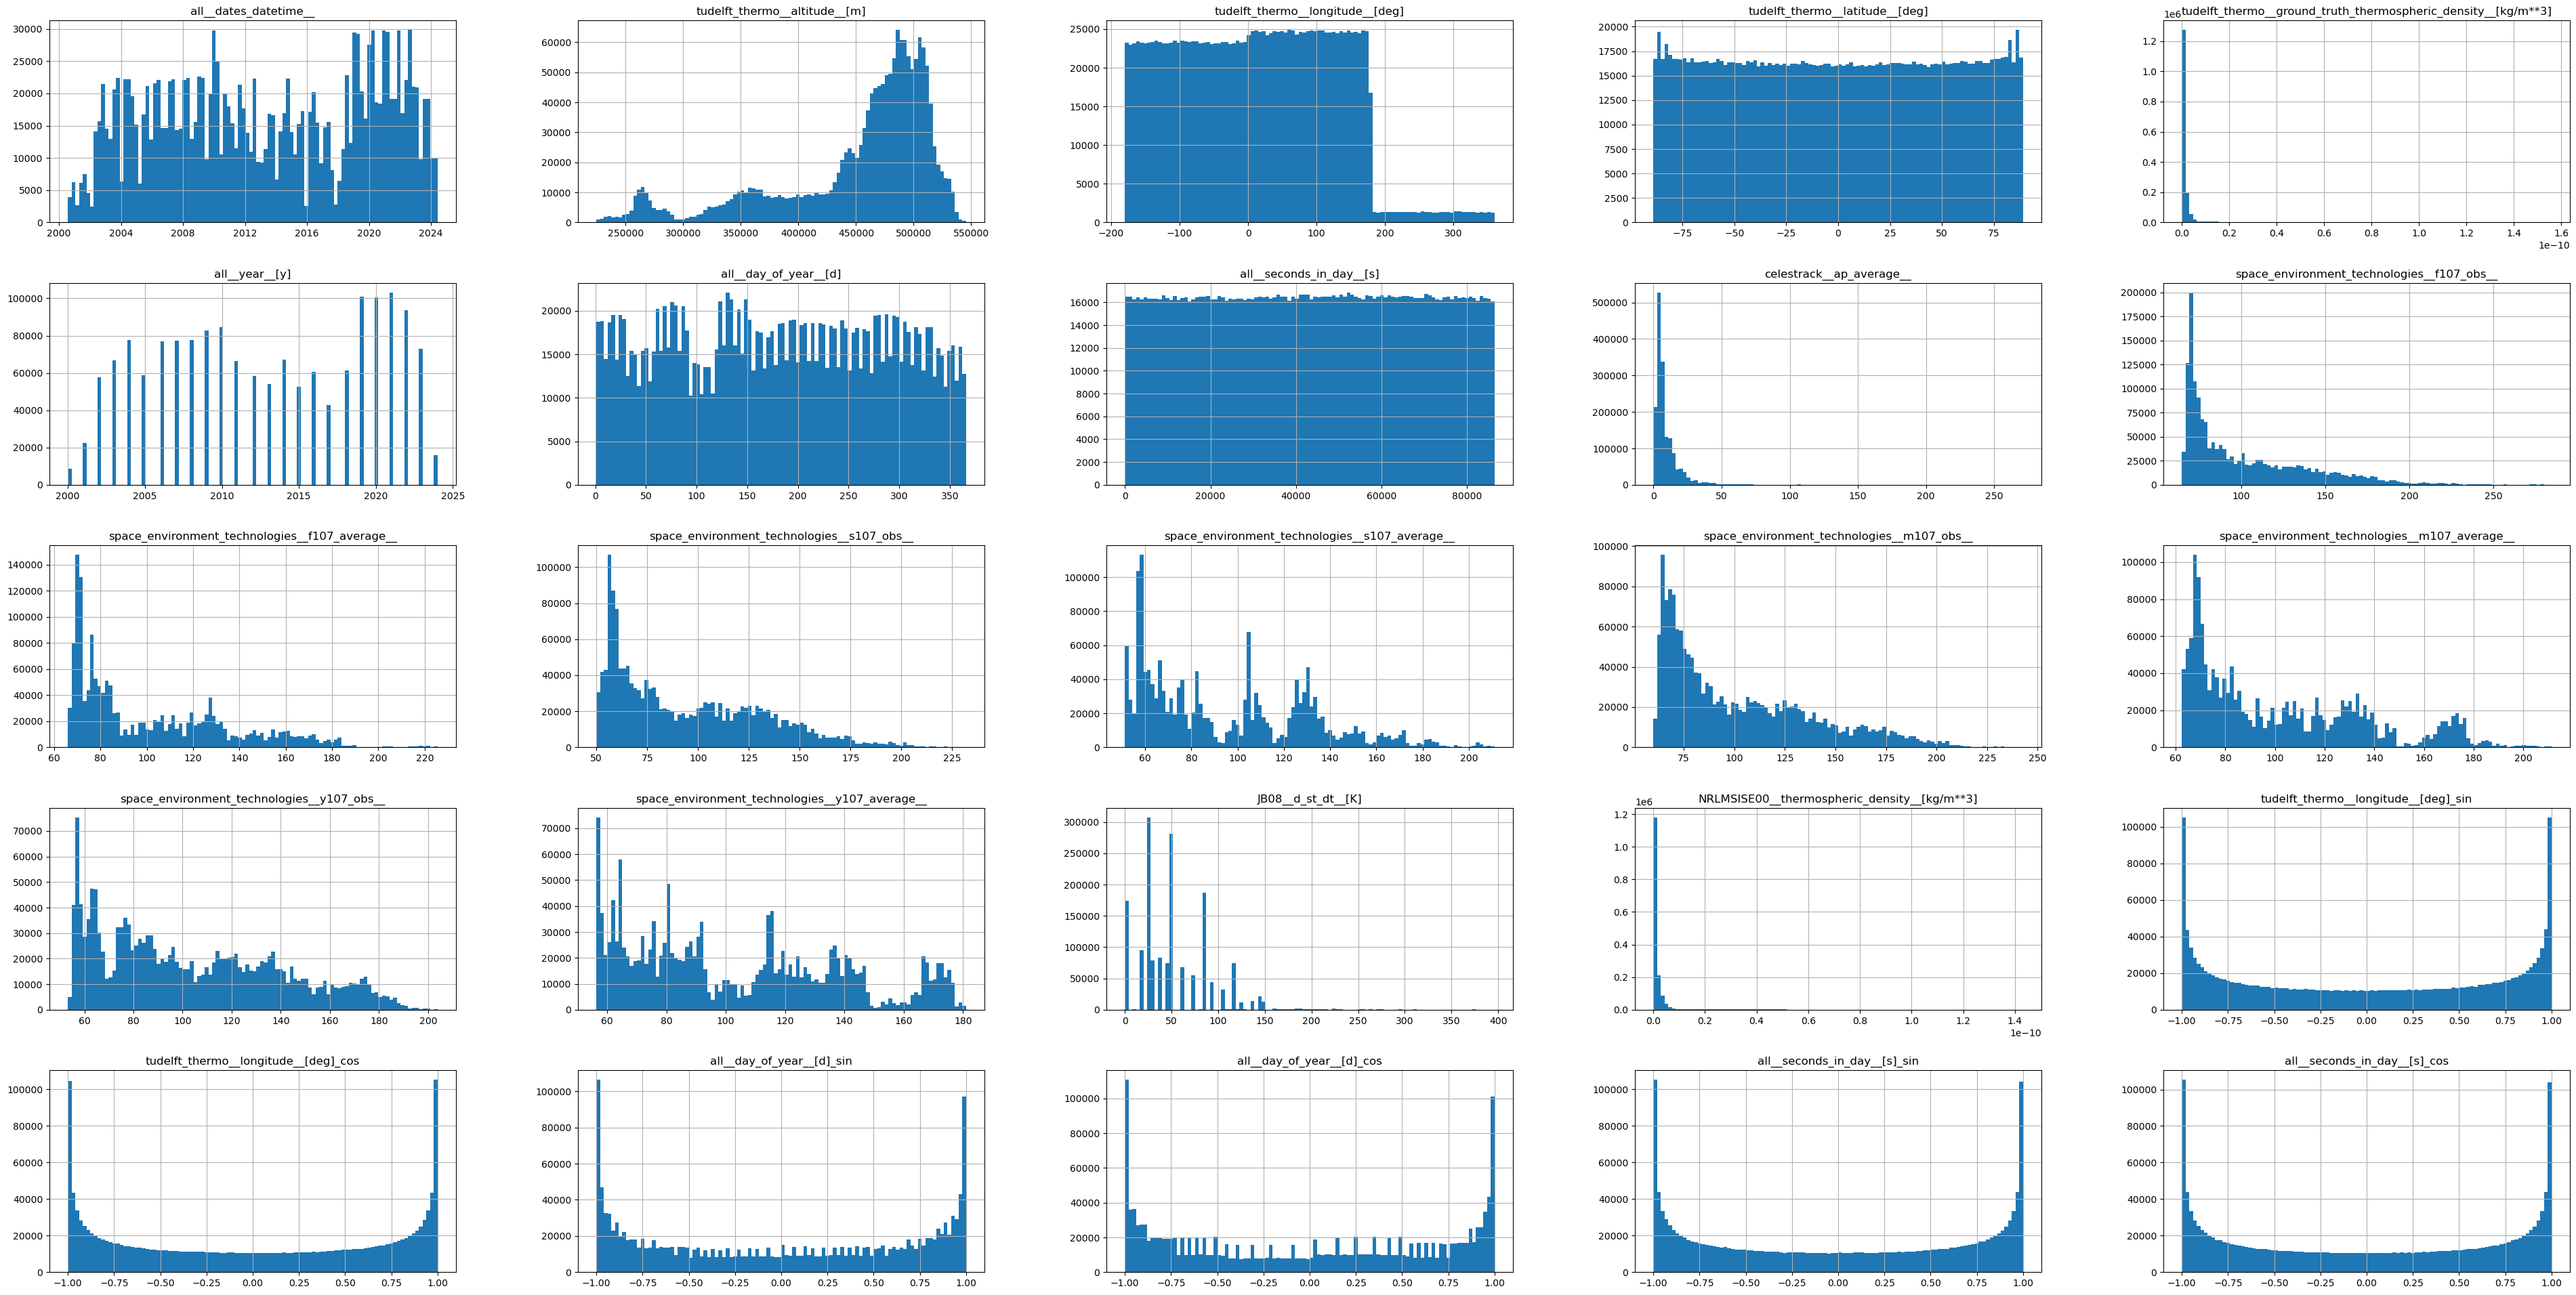

In [21]:
import matplotlib.pyplot as plt
df_train.hist(figsize=(48,24),bins=100)

In [18]:
#df[‘norm_den’] = df[‘den’].apply(min_max_norm)

df_test['tudelft_thermo__altitude__[m]'].std()
df_val['tudelft_thermo__altitude__[m]'].std()
df_train['tudelft_thermo__altitude__[m]'].std()

68239.27173069003

In [110]:
karman_dataset.data_thermo["data"].iloc[karman_dataset.val_indices]


,all__dates_datetime__,tudelft_thermo__altitude__[m],tudelft_thermo__longitude__[deg],tudelft_thermo__latitude__[deg],tudelft_thermo__ground_truth_thermospheric_density__[kg/m**3],tudelft_thermo__satellite__,all__year__[y],all__day_of_year__[d],all__seconds_in_day__[s],celestrack__ap_average__,...,space_environment_technologies__y107_obs__,space_environment_technologies__y107_average__,JB08__d_st_dt__[K],NRLMSISE00__thermospheric_density__[kg/m**3],tudelft_thermo__longitude__[deg]_sin,tudelft_thermo__longitude__[deg]_cos,all__day_of_year__[d]_sin,all__day_of_year__[d]_cos,all__seconds_in_day__[s]_sin,all__seconds_in_day__[s]_cos
10797,2001-02-01 00:08:47,471167.425,-53.627772,59.054704,1.601432e-12,champ,2001,32,527.0,8.0,...,158.7,157.2,94.0,9.634144e-13,-0.805181,0.593029,0.508671,0.860961,0.038316,0.999266
10798,2001-02-01 00:16:37,476753.631,10.471672,87.117537,1.197098e-12,champ,2001,32,997.0,8.0,...,158.7,157.2,94.0,8.706325e-13,0.181749,0.983345,0.508671,0.860961,0.072443,0.997373
10799,2001-02-01 00:37:57,441407.040,114.077200,9.035158,2.121972e-12,champ,2001,32,2277.0,8.0,...,158.7,157.2,94.0,1.803955e-12,0.912997,-0.407967,0.508671,0.860961,0.164838,0.986321
10800,2001-02-01 01:16:37,440772.693,-77.442031,-39.557722,2.690504e-12,champ,2001,32,4597.0,8.0,...,158.7,157.2,94.0,2.604165e-12,-0.976077,0.217427,0.508671,0.860961,0.328122,0.944635
10801,2001-02-01 01:50:17,476682.437,6.441944,87.278387,1.436534e-12,champ,2001,32,6617.0,8.0,...,158.7,157.2,94.0,8.734228e-13,0.112196,0.993686,0.508671,0.860961,0.462860,0.886432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025801,2024-03-31 23:38:52,492376.178,-58.640000,75.183000,1.053944e-12,grace_c,2024,91,85132.0,8.0,...,184.0,172.1,50.0,1.180655e-12,-0.853914,0.520414,0.999769,0.021516,-0.091867,0.995771
2025802,2024-03-31 23:44:30,536257.326,-132.072953,-74.965000,6.576717e-13,swarm_b,2024,91,85470.0,8.0,...,184.0,172.1,50.0,5.456622e-13,-0.742292,-0.670076,0.999769,0.021516,-0.067365,0.997728
2025803,2024-03-31 23:47:02,491110.925,-57.824000,44.075000,1.034331e-12,grace_c,2024,91,85622.0,8.0,...,184.0,172.1,50.0,1.247844e-12,-0.846416,0.532522,0.999769,0.021516,-0.056332,0.998412
2025804,2024-03-31 23:54:42,490319.201,-59.028000,14.732000,6.861283e-13,grace_c,2024,91,86082.0,8.0,...,184.0,172.1,50.0,1.122098e-12,-0.857419,0.514619,0.999769,0.021516,-0.022906,0.999738


In [111]:
karman_dataset.data_thermo["data"].iloc[karman_dataset.train_indices]

,all__dates_datetime__,tudelft_thermo__altitude__[m],tudelft_thermo__longitude__[deg],tudelft_thermo__latitude__[deg],tudelft_thermo__ground_truth_thermospheric_density__[kg/m**3],tudelft_thermo__satellite__,all__year__[y],all__day_of_year__[d],all__seconds_in_day__[s],celestrack__ap_average__,...,space_environment_technologies__y107_obs__,space_environment_technologies__y107_average__,JB08__d_st_dt__[K],NRLMSISE00__thermospheric_density__[kg/m**3],tudelft_thermo__longitude__[deg]_sin,tudelft_thermo__longitude__[deg]_cos,all__day_of_year__[d]_sin,all__day_of_year__[d]_cos,all__seconds_in_day__[s]_sin,all__seconds_in_day__[s]_cos
0,2000-07-29 01:02:47,464668.381,1.157470,28.369746,1.277367e-12,champ,2000,211,3767.0,27.0,...,181.8,167.4,105.0,1.034151e-12,0.020200,0.999796,-0.455907,-0.890028,0.270540,0.962709
1,2000-07-29 01:08:37,453642.942,0.878134,5.884984,1.686120e-12,champ,2000,211,4117.0,27.0,...,181.8,167.4,105.0,1.486250e-12,0.015326,0.999883,-0.455907,-0.890028,0.294954,0.955512
2,2000-07-29 01:09:37,452193.023,0.810949,2.020515,1.702076e-12,champ,2000,211,4177.0,27.0,...,181.8,167.4,105.0,1.533841e-12,0.014153,0.999900,-0.455907,-0.890028,0.299120,0.954215
3,2000-07-29 01:41:47,448598.031,168.510506,-57.890875,2.756074e-12,champ,2000,211,6107.0,27.0,...,181.8,167.4,105.0,2.573241e-12,0.199188,-0.979961,-0.455907,-0.890028,0.429672,0.902985
4,2000-07-29 01:44:17,447646.440,169.164846,-48.282622,2.818392e-12,champ,2000,211,6257.0,27.0,...,181.8,167.4,105.0,2.903693e-12,0.187984,-0.982172,-0.455907,-0.890028,0.439496,0.898244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2036268,2024-05-31 23:07:30,480454.781,-102.727319,79.790739,1.298487e-12,swarm_a,2024,152,83250.0,10.0,...,180.2,166.1,146.0,2.165198e-12,-0.975430,-0.220311,0.516062,-0.856551,-0.226872,0.973925
2036269,2024-05-31 23:08:00,480273.559,-100.475341,77.938659,1.320759e-12,swarm_a,2024,152,83280.0,10.0,...,180.2,166.1,146.0,2.206550e-12,-0.983333,-0.181812,0.516062,-0.856551,-0.224746,0.974417
2036270,2024-05-31 23:16:00,474835.203,-92.893237,47.571235,1.626814e-12,swarm_a,2024,152,83760.0,10.0,...,180.2,166.1,146.0,2.625791e-12,-0.998725,-0.050475,0.516062,-0.856551,-0.190601,0.981668
2036271,2024-05-31 23:32:00,507459.464,-34.700987,22.042681,4.643646e-13,swarm_b,2024,152,84720.0,10.0,...,180.2,166.1,146.0,9.499329e-13,-0.569294,0.822134,0.516062,-0.856551,-0.121657,0.992572


In [89]:
batch_size = 1024
train_minibatch = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
)

In [35]:
class AverageMeter(object):
    """Computes and stores the average and current value"""

    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

        self.min = np.inf
        self.max = -np.inf
        

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

        #self.max = np.max((self.max,val),axis=0)
        #self.min = np.min((self.min,val),axis=0)

In [36]:
altitude_bins_classification = {'0-200 km': 0,
                                '200-250 km': 1,
                                '250-300 km': 2,
                                '300-350 km': 3,
                                '350-400 km': 4,
                                '400-450 km': 5,
                                '450-500 km': 6,
                                '500-550 km': 7,
                                '550-600 km': 8}

solar_activity_bins_classification = {'F10.7: 0-70 (low)': 0,
                                      'F10.7: 70-150 (moderate)': 1,
                                      'F10.7: 150-200 (moderate-high)': 2,
                                      'F10.7: 200 (high)': 3}

storm_types = {
    "G0": 0,
    "G1": 1,
    "G2": 2,
    "G3": 3,
    "G4": 4,
    "G5": 5,
}

In [91]:
avg_meters = {}
exclude = ["date"]
for batch_idx,el in enumerate(train_minibatch):
    print(el)
    # for k,v in el.items():

    #     if k in exclude:
    #         continue 

    #     if k not in avg_meters:
    #         avg_meters[k] = AverageMeter()
        
    #     match k:
    #         case 'geomagnetic_storm_G_class':
    #             avg_meters[k].update(storm_types[v])
    #         case 'altitude_bins': 
    #             avg_meters[k].update(altitude_bins_classification[v])
    #         case 'solar_activity_bins':
    #             avg_meters[k].update(solar_activity_bins_classification[v])
    #         case _:
    #             print(v)
    #             avg_meters[k].update(v)

{'instantaneous_features': tensor([[ 0.4965,  0.3186, -0.8007,  ..., -0.8900,  0.2705,  0.9627],
        [ 0.4278,  0.0661, -0.8007,  ..., -0.8900,  0.2950,  0.9555],
        [ 0.4187,  0.0227, -0.8007,  ..., -0.8900,  0.2991,  0.9542],
        ...,
        [ 0.5963, -0.6264, -0.8672,  ..., -0.4444, -0.4013, -0.9159],
        [ 0.7023, -0.5909, -0.8672,  ..., -0.4444, -0.4752, -0.8799],
        [ 0.4131,  0.3565, -0.8672,  ..., -0.4444, -0.5573, -0.8303]]), 'nrlmsise00': tensor([1.0342e-12, 1.4862e-12, 1.5338e-12,  ..., 1.2267e-12, 1.0262e-12,
        2.8083e-12]), 'exponential_atmosphere': tensor([1.2454e-12, 1.4929e-12, 1.5289e-12,  ..., 9.5732e-13, 7.2383e-13,
        1.5520e-12]), 'target': tensor([ 0.0048,  0.0623,  0.0642,  ..., -0.0883, -0.0709,  0.1438]), 'ground_truth': tensor([1.2774e-12, 1.6861e-12, 1.7021e-12,  ..., 8.1535e-13, 8.8638e-13,
        2.4996e-12]), 'ap_average': tensor([27., 27., 27.,  ..., 18., 18., 18.]), 'geomagnetic_storm_G_class': ['G0', 'G0', 'G0', 'G0', 

KeyboardInterrupt: 

In [58]:
a = test_dataset[0]['instantaneous_features']
b = 1

print(a)
print(np.max((a,b)))

tensor([ 0.4044,  0.5708, -0.9557, -0.3850,  0.2604,  0.1726,  0.5447, -0.0927,
         0.3417,  0.2398,  0.6608, -0.7778, -0.9854, -0.1705,  0.8498,  0.5271,
         0.1569,  0.9876])


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.